   CustomerID  Gendre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Explained Variance Ratio:
[0.33690046 0.26230645]


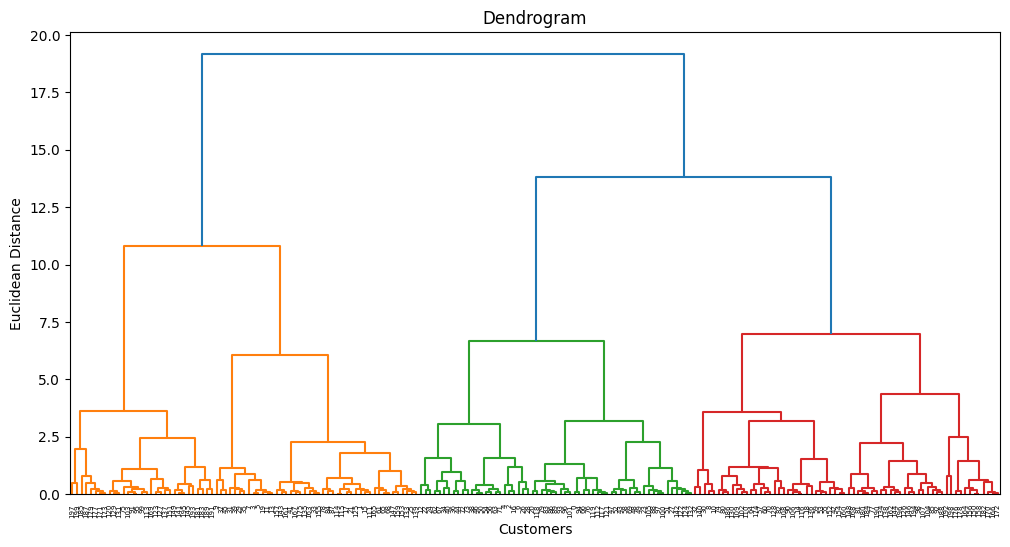

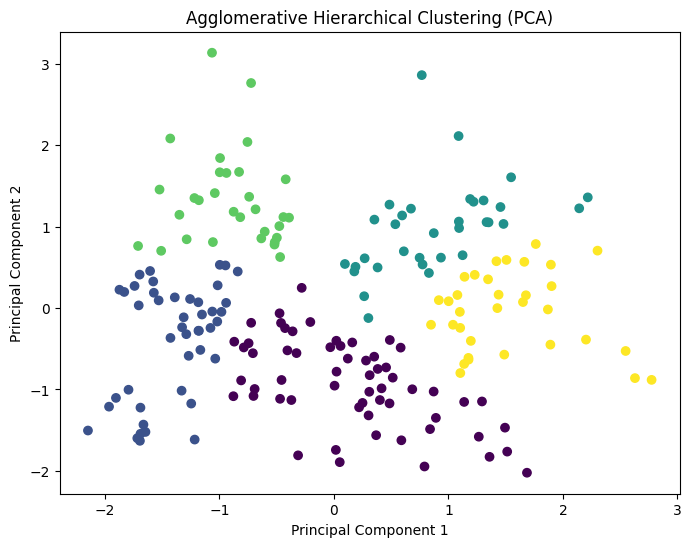


Cluster Counts Cluster
0    59
1    44
4    33
2    33
3    31
Name: count, dtype: int64
Cluster
0    59
1    44
2    33
3    31
4    33
Name: count, dtype: int64


In [6]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

# ==========================
# Data Preprocessing
# ==========================

# Remove CustomerID
df = df.drop("CustomerID", axis=1)

# Encode Gendre column
le = LabelEncoder()
df["Gendre"] = le.fit_transform(df["Gendre"])

# Features
X = df.copy()

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================
# PCA (Reduce dimensions)
# ==========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ==========================
# Dendrogram
# ==========================

plt.figure(figsize=(12,6))

linked = linkage(
    X_pca,
    method='ward'
)

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

# ==========================
# Agglomerative Clustering
# ==========================

hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

y_pred = hc.fit_predict(X_pca)

# ==========================
# Cluster Visualization
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_pred
)

plt.title("Agglomerative Hierarchical Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# ==========================
# Add cluster labels
# ==========================

df["Cluster"] = y_pred

# Cluster counts
print(df["Cluster"].value_counts().sort_index())